In [9]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

## Selecting databases

In [10]:
japan_adidas = pd.read_csv('JP_Adidas.csv')
usa_adidas = pd.read_csv('US_Adidas.csv')

## Cleaning up 

In [19]:
japan_adidas['sku'] = japan_adidas['sku'].str.split('_').str[0]
usa_adidas['sku'] = usa_adidas['sku'].str.split('_').str[0]

usa_adidas = usa_adidas.drop_duplicates(subset='sku')
japan_adidas = japan_adidas.drop_duplicates(subset='sku')

# Rate as of march 2026
yen_to_usd = japan_adidas['price_local'] * 0.0063
japan_adidas['price_local'] = japan_adidas['price_local'] * 0.0063
japan_adidas['sale_price_local'] = japan_adidas['sale_price_local'] * 0.0063

## Mapping Japanese categories to English

In [12]:
translating_jp_categories = {
    'ゴルフ': 'Golf',
    'ライフスタイル': 'Lifestyle',
    'ウォーキング': 'Walking',
    'サッカー': 'Soccer',
    'ランニング': 'Running',
    'シューズ': 'Shoes',
    'トレイルランニング': 'Trail Running'
}

## Filtering 

In [13]:
usa_adidas_running = usa_adidas[usa_adidas['category'] == 'Running']
japan_adidas['category'] = japan_adidas['category'].map(translating_jp_categories)
japan_adidas_running = japan_adidas[japan_adidas['category'] == 'Running']
japan_adidas_running = japan_adidas_running[['product_name', 'model_number', 'price_local', 'sale_price_local', 'category', 'sku']] 
usa_adidas_running = usa_adidas_running[['product_name', 'model_number', 'price_local', 'sale_price_local', 'category', 'sku']] 

## Master DataFrame

In [15]:
master_df = pd.merge(usa_adidas_running, japan_adidas_running, on='model_number')
master_df = master_df.rename(columns={'price_local_y': 'price_local_japan_usd', 'price_local_x': 'price_local_usa_usd'})
master_df['price_diff'] = master_df['price_local_usa_usd'] - master_df['price_local_japan_usd']
master_df = master_df.drop_duplicates(subset='model_number')

## Visualization

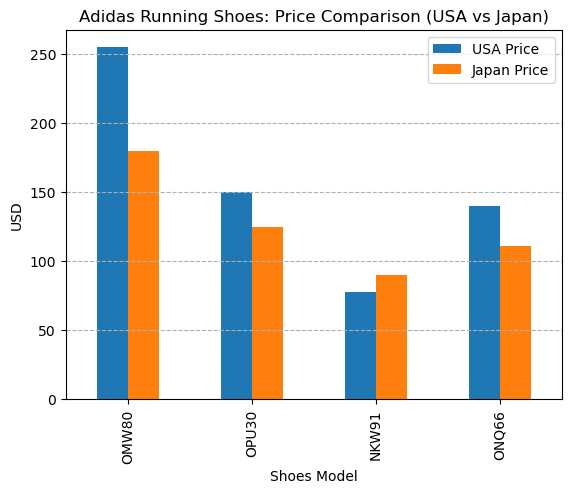

In [18]:
plot_diff = master_df.set_index('model_number')
ax = plot_diff[['price_local_usa_usd', 'price_local_japan_usd']].plot(kind='bar')
plt.title('Adidas Running Shoes: Price Comparison (USA vs Japan)')
plt.ylabel('USD')
plt.xlabel('Shoes Model')
plt.legend(['USA Price', 'Japan Price'])
plt.grid(axis='y', linestyle='--')

plt.show()